# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

Updated Corpus


In [18]:
corpus = '''Lionel Messi is widely regarded as one of the greatest football players of all time. Born on June 24, 1987, in Rosario, Argentina, Messi displayed extraordinary football talent from a very young age. Despite facing a growth hormone deficiency during childhood, he never gave up on his dream of becoming a professional footballer. At the age of 13, he moved to Spain and joined the youth academy of FC Barcelona, where his remarkable skills quickly attracted attention. Over the years, Messi became the club’s most iconic player, helping Barcelona win numerous domestic and international titles. His exceptional dribbling, vision, passing accuracy, and goal-scoring ability set him apart from other players.

Throughout his career, Messi has won multiple Ballon d'Or awards, recognizing him as the best football player in the world. He has broken countless records, including becoming one of the highest goal scorers in football history. Beyond his individual achievements, Messi has always been a team player who values collective success. One of the most memorable moments of his career came in 2022 when he captained the Argentina national football team to victory in the FIFA World Cup, fulfilling a lifelong dream and bringing immense joy to millions of Argentine fans.

Apart from football, Messi is admired for his humility, discipline, and charitable work. Through the Leo Messi Foundation, he supports education and healthcare initiatives for children around the world. His inspiring journey from a young boy with challenges to a global football legend continues to motivate people across generations.

'''
print(corpus)

Lionel Messi is widely regarded as one of the greatest football players of all time. Born on June 24, 1987, in Rosario, Argentina, Messi displayed extraordinary football talent from a very young age. Despite facing a growth hormone deficiency during childhood, he never gave up on his dream of becoming a professional footballer. At the age of 13, he moved to Spain and joined the youth academy of FC Barcelona, where his remarkable skills quickly attracted attention. Over the years, Messi became the club’s most iconic player, helping Barcelona win numerous domestic and international titles. His exceptional dribbling, vision, passing accuracy, and goal-scoring ability set him apart from other players.

Throughout his career, Messi has won multiple Ballon d'Or awards, recognizing him as the best football player in the world. He has broken countless records, including becoming one of the highest goal scorers in football history. Beyond his individual achievements, Messi has always been a tea

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [19]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 162
X shape: (248, 110)
y shape: (248,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [20]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


## Updates
- Embedding from 32 to 128
- Hidden Units from 64 to 128
- Epochs from 100 to 200

In [21]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [22]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


## Updates
- Embedding from 32 to 128
- Hidden Units from 64 to 128
- Epochs from 100 to 200

In [23]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [24]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## Updates
- Embedding from 32 to 128
- Hidden Units from 64 to 128
- Epochs from 100 to 200

In [25]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

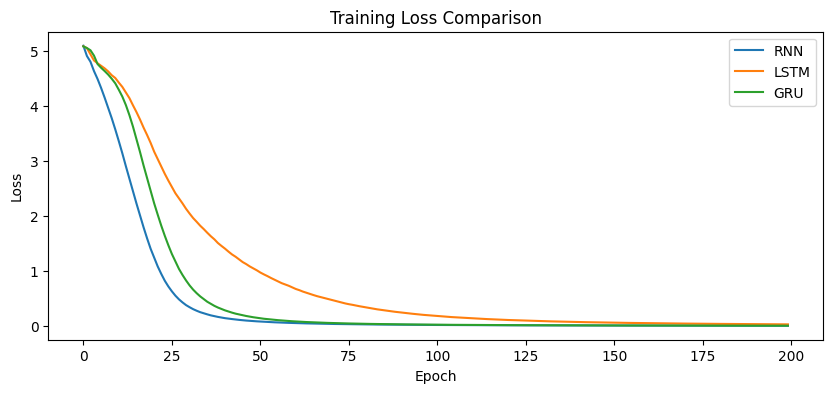

In [26]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [27]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [32]:
print("RNN :", generate_text(rnn_model, "One of the most memorable moments of his career came", 5))
print("LSTM:", generate_text(lstm_model, "Messi became the club’s most iconic player", 5))
print("GRU :", generate_text(gru_model, "Lionel Messi is widely regarded", 5))

RNN : One of the most memorable moments of his career came in 2022 when he captained
LSTM: Messi became the club’s most iconic player of the greatest football players
GRU : Lionel Messi is widely regarded as one of the greatest


## Updates
- Generating 10 words instead of 5

In [33]:
print("RNN :", generate_text(rnn_model, "One of the most memorable moments of his career came", 10))
print("LSTM:", generate_text(lstm_model, "Messi became the club’s most iconic player", 10))
print("GRU :", generate_text(gru_model, "Lionel Messi is widely regarded", 10))

RNN : One of the most memorable moments of his career came in 2022 when he captained the argentina national football team
LSTM: Messi became the club’s most iconic player of the greatest football players of all time born on
GRU : Lionel Messi is widely regarded as one of the greatest football players of all time


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**